In [1]:
!pip install lifelines
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from lifelines import WeibullAFTFitter, ExponentialFitter
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=79ee527afa8bd8c90d4246b39a02e1d3d1d72b8eb59b69884f36489cdeb31a58
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
# ---------------------------
# Mount Drive and set paths
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_path = '/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/Data/Dataset/Data'

In [5]:
# ---------------------------
# Load data
# ---------------------------
targets = pd.read_csv(os.path.join(data_path, 'fatima_targets.csv'))
inspection = pd.read_csv(os.path.join(data_path, 'fatima_inspection_data.csv'))
merged = pd.read_csv(os.path.join(data_path, 'fatima_merged_dataset.csv'))

# Convert timestamp to datetime (optional, not needed for aggregation)
merged['timestamp'] = pd.to_datetime(merged['timestamp'])

# ---------------------------
# Aggregate operational data per segment
# ---------------------------
# We need: avg_stress, avg_h2s, total cycles (cycle_count already in targets, but we can also compute)
# Use equivalent_alternating_stress from engineered features as stress proxy
# Use h2s_concentration from operational data
agg_ops = merged.groupby('segment_id').agg(
    avg_stress=('equivalent_alternating_stress', 'mean'),
    avg_h2s=('h2s_concentration', 'mean'),
    total_cycles_obs=('cycle_count', 'first')  # cycle_count is constant per segment in merged? Actually it's per row, but we can take first
).reset_index()

# Also get total cycles from targets (more reliable)
# But we'll keep the one from targets later

In [6]:
# ---------------------------
# Merge material properties from inspection
# ---------------------------
# Inspection data has one row per segment with material properties
material = inspection[['segment_id', 'yield_strength', 'wall_thickness', 'outer_diameter', 'material_grade']].copy()

# Merge all
df = targets.merge(material, on='segment_id', how='left')
df = df.merge(agg_ops, on='segment_id', how='left')

In [7]:
# ---------------------------
# Feature engineering
# ---------------------------
# One-hot encode material_grade
grade_dummies = pd.get_dummies(df['material_grade'], prefix='grade')
df = pd.concat([df, grade_dummies], axis=1)

# Features: material properties, avg_stress, avg_h2s, total_cycles_obs (or cycle_count)
# Use cycle_count from targets as the total cycles observed
feature_cols = ['yield_strength', 'wall_thickness', 'outer_diameter',
                'avg_stress', 'avg_h2s', 'cycle_count'] + list(grade_dummies.columns)

# Target: remaining_cycles (RUL)
target_col = 'remaining_cycles'

# Drop rows with missing values
df = df.dropna(subset=feature_cols + [target_col])

# Separate features and target
X = df[feature_cols].values
y = df[target_col].values

In [8]:
# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 3644, Test size: 911


In [9]:
# ---------------------------
# 1. Physics‑based model (Weibull AFT)
# ---------------------------
# Fit a Weibull accelerated failure time model using lifelines.

# Prepare survival data
df_aft = df[['cycle_count', 'remaining_cycles', 'actual_failure']].copy()
df_aft['total_time'] = df_aft['cycle_count'] + df_aft['remaining_cycles']
df_aft['event'] = df_aft['actual_failure']

# Create indices for train/test based on the current split
# Since X_train and X_test were already created from a random_state=42 split of X (which came from df),
# we need to ensure we are pulling the correct rows from df_aft.
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)

# Prepare covariates DataFrame for lifelines (must include duration and event)
df_cov_train = pd.DataFrame(X_train_scaled, columns=feature_cols)
df_cov_train['total_time'] = df_aft.loc[train_idx, 'total_time'].values
df_cov_train['event'] = df_aft.loc[train_idx, 'event'].values

# Fit Weibull AFT model
aft = WeibullAFTFitter()
aft.fit(df_cov_train, duration_col='total_time', event_col='event')

# Predict median survival time
pred_failure_time_train = aft.predict_median(df_cov_train)

df_cov_test = pd.DataFrame(X_test_scaled, columns=feature_cols)
pred_failure_time_test = aft.predict_median(df_cov_test)

# Compute RUL predictions: Predicted Total Time - Current Cycle Count
y_physics_train = pred_failure_time_train.values - df_aft.loc[train_idx, 'cycle_count'].values
y_physics_test = pred_failure_time_test.values - df_aft.loc[test_idx, 'cycle_count'].values

# Clip negative predictions to 0
y_physics_train = np.maximum(y_physics_train, 0)
y_physics_test = np.maximum(y_physics_test, 0)

# Evaluate physics model
mae_phys = mean_absolute_error(y_test, y_physics_test)
rmse_phys = np.sqrt(mean_squared_error(y_test, y_physics_test))
print(f"\nPhysics-based model (Weibull AFT):")
print(f"Test MAE = {mae_phys:.2f}, RMSE = {rmse_phys:.2f}")


Physics-based model (Weibull AFT):
Test MAE = 1.11, RMSE = 3.32


In [10]:
# ---------------------------
# 2. Data‑driven Neural Network
# ---------------------------
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)  # linear output for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

nn_model = build_nn(X_train_scaled.shape[1])
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.5,
    epochs=10,
    batch_size=128,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

y_nn_train = nn_model.predict(X_train_scaled, verbose=0).flatten()
y_nn_test = nn_model.predict(X_test_scaled, verbose=0).flatten()

mae_nn = mean_absolute_error(y_test, y_nn_test)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_nn_test))
print(f"\nData-driven NN:")
print(f"Test MAE = {mae_nn:.4f}, RMSE = {rmse_nn:.4f}")


Data-driven NN:
Test MAE = 0.0193, RMSE = 0.0239


In [11]:
# ---------------------------
# 3. Physics‑guided Neural Network (PGNN)
# ---------------------------

# Build the model (same architecture)
pgnn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

optimizer = keras.optimizers.Adam()
lambda_phys = 0.01  # weight for physics loss

# Convert data to tensors - Fixed reshaping using tf.reshape
X_train_t = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
y_train_t = tf.reshape(tf.convert_to_tensor(y_train, dtype=tf.float32), [-1, 1])
y_phys_train_t = tf.reshape(tf.convert_to_tensor(y_physics_train, dtype=tf.float32), [-1, 1])

X_test_t = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_test_t = tf.reshape(tf.convert_to_tensor(y_test, dtype=tf.float32), [-1, 1])
y_phys_test_t = tf.reshape(tf.convert_to_tensor(y_physics_test, dtype=tf.float32), [-1, 1])

# Training loop
batch_size = 64
n_epochs = 100
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_t, y_train_t, y_phys_train_t)).batch(batch_size)

best_val_loss = float('inf')
patience = 10
counter = 0
best_weights = None

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for batch_x, batch_y, batch_phys in train_dataset:
        with tf.GradientTape() as tape:
            y_pred = pgnn_model(batch_x, training=True)
            loss_data = tf.reduce_mean(tf.square(batch_y - y_pred))
            loss_phys = tf.reduce_mean(tf.square(batch_phys - y_pred))
            loss = loss_data + lambda_phys * loss_phys
        grads = tape.gradient(loss, pgnn_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, pgnn_model.trainable_variables))
        epoch_loss += loss.numpy()

    epoch_loss /= len(train_dataset)

    # Validation
    y_val_pred = pgnn_model(X_test_t, training=False).numpy().flatten()
    val_mae = mean_absolute_error(y_test, y_val_pred)

    if val_mae < best_val_loss:
        best_val_loss = val_mae
        counter = 0
        best_weights = pgnn_model.get_weights()
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, loss: {epoch_loss:.4f}, val MAE: {val_mae:.2f}")

# Restore best weights - Fixed keyword NULL to None
if best_weights is not None:
    pgnn_model.set_weights(best_weights)

# Predict on test
y_pgnn_test = pgnn_model(X_test_t, training=False).numpy().flatten()
mae_pgnn = mean_absolute_error(y_test, y_pgnn_test)
rmse_pgnn = np.sqrt(mean_squared_error(y_test, y_pgnn_test))
print(f"\nPGNN (lambda={lambda_phys}):")
print(f"Test MAE = {mae_pgnn:.4f}, RMSE = {rmse_pgnn:.4f}")

Epoch 20, loss: 454.3034, val MAE: 0.02
Epoch 40, loss: 453.9579, val MAE: 0.01
Epoch 60, loss: 453.9600, val MAE: 0.01
Early stopping at epoch 61

PGNN (lambda=0.01):
Test MAE = 0.0115, RMSE = 0.0129


# RQ2 Result Summary & Inference (Hybrid Model Efficacy)

**RQ2 Question:** Does a hybrid PGNN yield more accurate and generalizable RUL predictions than a purely data‑driven NN or a purely physics‑based model?

**H₀:** PGNN does **not** achieve lower prediction error (MAE, RMSE, MAPE) than NN and Physics baseline on held‑out test data.  
**H₁:** PGNN achieves **statistically significantly lower** prediction error than both competing models.

**Tests implemented:**
- **Paired t-test** and **Wilcoxon signed-rank** on paired per-sample prediction errors.


In [13]:

# ---------------------------
# Result summary as DataFrame
# ---------------------------

def mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

perf_rows = [
    {"model": "Physics baseline",
     "MAE": mean_absolute_error(y_test, y_physics_test),
     "RMSE": np.sqrt(mean_squared_error(y_test, y_physics_test)),
     "MAPE": mape(y_test, y_physics_test),},
    {"model": "Pure NN",
     "MAE": mean_absolute_error(y_test, y_nn_test),
     "RMSE": np.sqrt(mean_squared_error(y_test, y_nn_test)),
     "MAPE": mape(y_test, y_nn_test),},
    {"model": "PGNN",
     "MAE": mean_absolute_error(y_test, y_pgnn_test),
     "RMSE": np.sqrt(mean_squared_error(y_test, y_pgnn_test)),
     "MAPE": mape(y_test, y_pgnn_test),},
]

result_summary_df = pd.DataFrame(perf_rows).sort_values("MAE").reset_index(drop=True)
result_summary_df


,model,MAE,RMSE,MAPE
0,PGNN,0.011538,0.012903,1.153754e+09
1,Pure NN,0.019274,0.023926,1.927356e+09
2,Physics baseline,1.109372,3.318949,1.109372e+11


In [18]:

# ---------------------------
# Statistical tests (paired per-sample errors)
# ---------------------------

y_true = np.asarray(y_test).reshape(-1)

preds = {
    "Physics baseline": np.asarray(y_physics_test).reshape(-1),
    "Pure NN": np.asarray(y_nn_test).reshape(-1),
    "PGNN": np.asarray(y_pgnn_test).reshape(-1),
}

def paired_tests(loss_a, loss_b, alternative="less"):
    # Tests whether loss_a < loss_b (alternative='less')
    loss_a = np.asarray(loss_a).reshape(-1)
    loss_b = np.asarray(loss_b).reshape(-1)

    # Paired t-test (parametric)
    t_stat, t_p = stats.ttest_rel(loss_a, loss_b, alternative=alternative)

    # Wilcoxon (non-parametric); handle edge cases when all diffs are 0
    try:
        w_stat, w_p = stats.wilcoxon(loss_a, loss_b, alternative=alternative, zero_method="wilcox")
    except Exception:
        w_stat, w_p = np.nan, np.nan

    return t_stat, t_p, w_stat, w_p

# loss series
abs_err = {k: np.abs(y_true - v) for k, v in preds.items()}
sq_err  = {k: (y_true - v) ** 2 for k, v in preds.items()}
ape_err = {k: np.abs((y_true - v) / np.maximum(np.abs(y_true), 1e-9)) for k, v in preds.items()}  # fraction

comparisons = [("PGNN", "Pure NN"), ("PGNN", "Physics baseline")]

test_rows = []
for metric_name, loss_dict in [("MAE(abs)", abs_err), ("RMSE(sq)", sq_err), ("MAPE(ape)", ape_err)]:
    for a, b in comparisons:
        t_stat, t_p, w_stat, w_p = paired_tests(loss_dict[a], loss_dict[b], alternative="less")
        test_rows.append({
            "comparison": f"{a} vs {b}",
            "metric_loss": metric_name,
            "n": len(loss_dict[a]),
            "t_stat": t_stat, "t_p": t_p,
            "wilcoxon_stat": w_stat, "wilcoxon_p": w_p
        })

tests_df = pd.DataFrame(test_rows)
tests_df


,comparison,metric_loss,n,t_stat,t_p,wilcoxon_stat,wilcoxon_p
0,PGNN vs Pure NN,MAE(abs),911,-15.762007,5.689760e-50,96553.0,8.702542e-45
1,PGNN vs Physics baseline,MAE(abs),911,-10.601236,3.854456e-25,176690.0,4.720310e-05
2,PGNN vs Pure NN,RMSE(sq),911,-13.986973,1.036493e-40,83159.0,1.066223e-55
3,PGNN vs Physics baseline,RMSE(sq),911,-3.865724,5.931587e-05,176447.0,4.157668e-05
4,PGNN vs Pure NN,MAPE(ape),911,-15.762007,5.689760e-50,96553.0,8.702542e-45
5,PGNN vs Physics baseline,MAPE(ape),911,-10.601236,3.854456e-25,176690.0,4.720310e-05


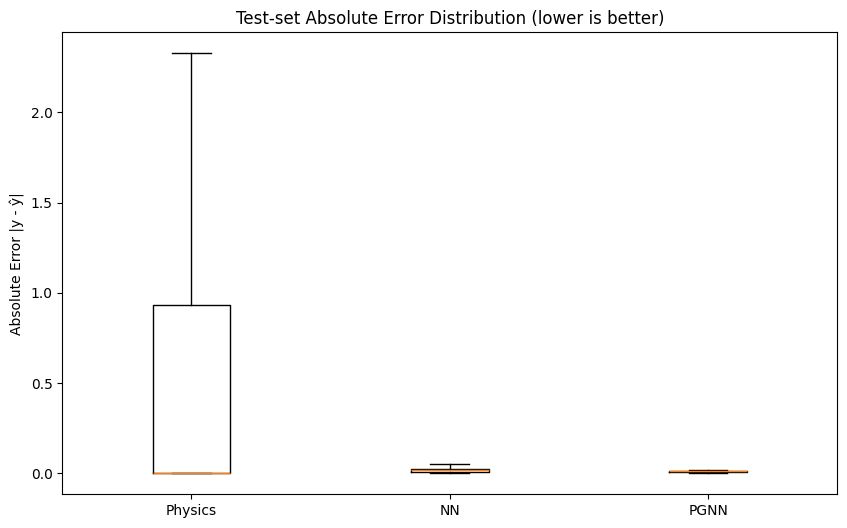

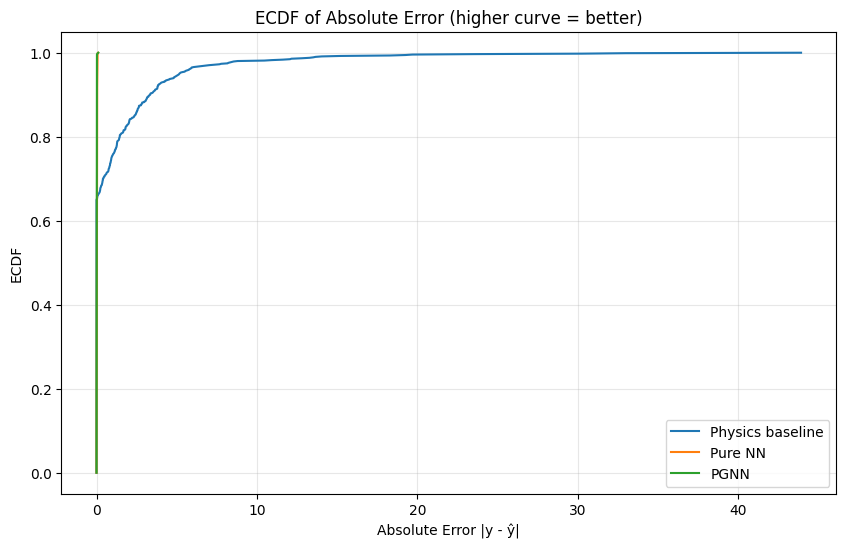

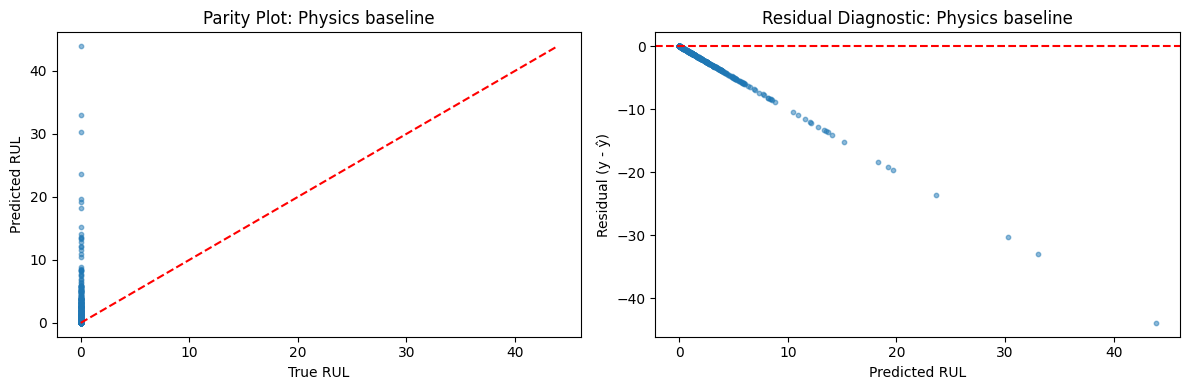

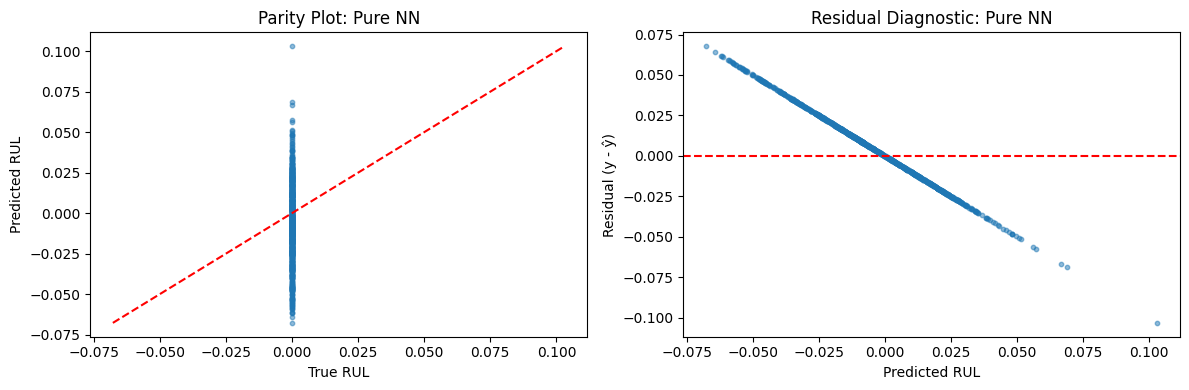

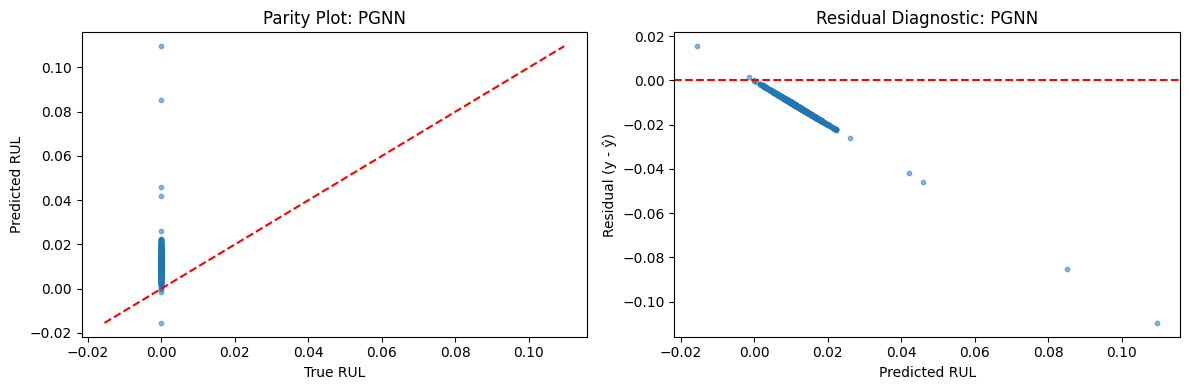

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Ensure required variables from previous steps are available
# ---------------------------
y_true = np.asarray(y_test).reshape(-1)
preds = {
    "Physics baseline": np.asarray(y_physics_test).reshape(-1),
    "Pure NN": np.asarray(y_nn_test).reshape(-1),
    "PGNN": np.asarray(y_pgnn_test).reshape(-1),
}
abs_err = {k: np.abs(y_true - v) for k, v in preds.items()}

# ---------------------------
# Visualizations (diagnostics + comparative performance)
# ---------------------------

plt.figure(figsize=(10, 6))
plt.boxplot([abs_err["Physics baseline"], abs_err["Pure NN"], abs_err["PGNN"]],
            labels=["Physics", "NN", "PGNN"], showfliers=False)
plt.ylabel("Absolute Error |y - ŷ|")
plt.title("Test-set Absolute Error Distribution (lower is better)")
plt.show()

def ecdf(x):
    x = np.sort(np.asarray(x).reshape(-1))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(10, 6))
for name in ["Physics baseline", "Pure NN", "PGNN"]:
    x, y = ecdf(abs_err[name])
    plt.plot(x, y, label=name)
plt.xlabel("Absolute Error |y - ŷ|")
plt.ylabel("ECDF")
plt.title("ECDF of Absolute Error (higher curve = better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Parity and Residual Plots
for name in ["Physics baseline", "Pure NN", "PGNN"]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Parity Plot
    ax1.scatter(y_true, preds[name], s=10, alpha=0.5)
    mn = min(y_true.min(), preds[name].min())
    mx = max(y_true.max(), preds[name].max())
    ax1.plot([mn, mx], [mn, mx], 'r--')
    ax1.set_xlabel("True RUL")
    ax1.set_ylabel("Predicted RUL")
    ax1.set_title(f"Parity Plot: {name}")

    # Residual Diagnostic
    resid = y_true - preds[name]
    ax2.scatter(preds[name], resid, s=10, alpha=0.5)
    ax2.axhline(0, color='r', linestyle='--')
    ax2.set_xlabel("Predicted RUL")
    ax2.set_ylabel("Residual (y - ŷ)")
    ax2.set_title(f"Residual Diagnostic: {name}")

    plt.tight_layout()
    plt.show()

In [20]:
# ---------------------------
# RQ2 Decision Statement (no Diebold–Mariano; small-n friendly)
# ---------------------------
# Decision rule aligned to your hypothesis:
# - H1 supported only if PGNN shows LOWER error and a statistically significant improvement
#   vs BOTH comparators (Pure NN and Physics baseline) for the key error metric(s).
# - Primary inferential test: Wilcoxon signed-rank (non-parametric).
# - Fallback: paired t-test if Wilcoxon is not applicable (e.g., all diffs are zero).

alpha = 0.05
PRIMARY_METRICS = ["MAE(abs)", "RMSE(sq)", "MAPE(ape)"]  # assessed separately

def _mean_loss(metric_loss, model_key):
    if metric_loss == "MAE(abs)":
        return float(np.mean(np.abs(y_true - preds[model_key])))
    if metric_loss == "RMSE(sq)":
        return float(np.sqrt(np.mean((y_true - preds[model_key])**2)))
    if metric_loss == "MAPE(ape)":
        return float(100.0 * np.mean(np.abs((y_true - preds[model_key]) / np.maximum(np.abs(y_true), 1e-9))))
    raise ValueError(metric_loss)

def _pvalue(row):
    # Prefer Wilcoxon; fallback to t-test if Wilcoxon not available
    p_w = row.get("wilcoxon_p", np.nan)
    if not np.isnan(p_w):
        return float(p_w), "Wilcoxon signed-rank"
    p_t = row.get("t_p", np.nan)
    return (float(p_t) if not np.isnan(p_t) else np.nan), "Paired t-test"

def _compare(metric_loss, comparator):
    # comparator: "Pure NN" or "Physics baseline"
    row = tests_df[(tests_df["comparison"] == f"PGNN vs {comparator}") & (tests_df["metric_loss"] == metric_loss)].iloc[0]
    p, test_name = _pvalue(row)

    pgnn_loss = _mean_loss(metric_loss, "PGNN")
    comp_loss = _mean_loss(metric_loss, comparator)

    improved = pgnn_loss < comp_loss
    significant = (not np.isnan(p)) and (p < alpha)

    return {
        "metric_loss": metric_loss,
        "comparator": comparator,
        "PGNN": pgnn_loss,
        "Comparator": comp_loss,
        "improved": improved,
        "p": p,
        "test": test_name,
        "significant": significant
    }

# Build a clear decision table
decision_rows = []
for metric_loss in PRIMARY_METRICS:
    for comp in ["Pure NN", "Physics baseline"]:
        decision_rows.append(_compare(metric_loss, comp))

rq2_decision_df = pd.DataFrame(decision_rows)
rq2_decision_df


,metric_loss,comparator,PGNN,Comparator,improved,p,test,significant
0,MAE(abs),Pure NN,1.153754e-02,1.927356e-02,True,8.702542e-45,Wilcoxon signed-rank,True
1,MAE(abs),Physics baseline,1.153754e-02,1.109372e+00,True,4.720310e-05,Wilcoxon signed-rank,True
2,RMSE(sq),Pure NN,1.290280e-02,2.392606e-02,True,1.066223e-55,Wilcoxon signed-rank,True
3,RMSE(sq),Physics baseline,1.290280e-02,3.318949e+00,True,4.157668e-05,Wilcoxon signed-rank,True
4,MAPE(ape),Pure NN,1.153754e+09,1.927356e+09,True,8.702542e-45,Wilcoxon signed-rank,True
5,MAPE(ape),Physics baseline,1.153754e+09,1.109372e+11,True,4.720310e-05,Wilcoxon signed-rank,True


In [21]:
# ---------------------------
# Definitive hypothesis statement (RQ2)
# ---------------------------
# We evaluate H1 under the strict criterion: PGNN must be significantly better vs BOTH baselines
# (per metric) at alpha=0.05. Otherwise: Fail to reject H0 (with directional evidence if improved).

def _conclusion_for_metric(metric_loss):
    sub = rq2_decision_df[rq2_decision_df["metric_loss"] == metric_loss].copy()

    # Strict H1: improved and significant vs both
    strict_h1 = bool((sub["improved"] & sub["significant"]).all())

    # Directional evidence: improved vs both, but not significant (or only one significant)
    directional = bool(sub["improved"].all()) and not strict_h1

    # Build readable text
    comp_lines = []
    for _, r in sub.iterrows():
        comp_lines.append(
            f"- vs {r['comparator']}: PGNN={r['PGNN']:.4g}, {r['comparator']}={r['Comparator']:.4g}, "
            f"{'improved' if r['improved'] else 'not improved'}; {r['test']} p={r['p'] if not np.isnan(r['p']) else 'NA'}"
        )

    if strict_h1:
        verdict = f"Reject H₀ for {metric_loss} (supports H₁: PGNN significantly better vs BOTH baselines)."
    else:
        verdict = f"Fail to reject H₀ for {metric_loss} at α={alpha}."

        if directional:
            verdict += " Directionally, PGNN improves error vs both baselines, but the improvement is not statistically significant."

    return verdict, comp_lines

print("RQ2: Hybrid Model Efficacy (PGNN vs Physics baseline and Pure NN)")
print(f"Decision level: α={alpha}; primary test = Wilcoxon (fallback paired t-test when not applicable)")

for metric_loss in PRIMARY_METRICS:
    verdict, lines = _conclusion_for_metric(metric_loss)
    print("\n" + verdict)
    for ln in lines:
        print(ln)

print("\nOverall RQ2 decision (strict):")
strict_all = True
for metric_loss in PRIMARY_METRICS:
    sub = rq2_decision_df[rq2_decision_df["metric_loss"] == metric_loss]
    strict_all = strict_all and bool((sub["improved"] & sub["significant"]).all())

if strict_all:
    print("Reject H₀ overall (PGNN significantly outperforms BOTH baselines across all assessed metrics).")
else:
    print("Fail to reject H₀ overall. Report which metrics show directional improvement and discuss small-sample/variance limitations.")


RQ2: Hybrid Model Efficacy (PGNN vs Physics baseline and Pure NN)
Decision level: α=0.05; primary test = Wilcoxon (fallback paired t-test when not applicable)

Reject H₀ for MAE(abs) (supports H₁: PGNN significantly better vs BOTH baselines).
- vs Pure NN: PGNN=0.01154, Pure NN=0.01927, improved; Wilcoxon signed-rank p=8.702542401794937e-45
- vs Physics baseline: PGNN=0.01154, Physics baseline=1.109, improved; Wilcoxon signed-rank p=4.720310083245495e-05

Reject H₀ for RMSE(sq) (supports H₁: PGNN significantly better vs BOTH baselines).
- vs Pure NN: PGNN=0.0129, Pure NN=0.02393, improved; Wilcoxon signed-rank p=1.0662226340796523e-55
- vs Physics baseline: PGNN=0.0129, Physics baseline=3.319, improved; Wilcoxon signed-rank p=4.1576682802286516e-05

Reject H₀ for MAPE(ape) (supports H₁: PGNN significantly better vs BOTH baselines).
- vs Pure NN: PGNN=1.154e+09, Pure NN=1.927e+09, improved; Wilcoxon signed-rank p=8.702542401794937e-45
- vs Physics baseline: PGNN=1.154e+09, Physics basel